In [180]:
from logging import warn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
import seaborn as sns
warnings.filterwarnings("ignore")

#### Load The Dataset ####

In [181]:
df=pd.read_csv("titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [182]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

#### Clean the Data ####

In [183]:
df=df.dropna(subset=['Embarked'])
# df['Age']=df['Age'].fillna(value=0,inplace=True)

In [184]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

#### Question 1 — What was the overall survival rate? ####

In [185]:
df['Survived'].sum()

np.int64(340)

In [186]:
df.shape[0]

889

In [187]:
survival_rate= (df['Survived'].sum()/df.shape[0])*100
survival_rate.round(2)

np.float64(38.25)

#### Question 2 — Did gender affect survival? (Most important question) ####

In [188]:
df.groupby("Sex")['Survived'].mean()*100

Sex
female    74.038462
male      18.890815
Name: Survived, dtype: float64

In [189]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


#### Question 3 — Did ticket class affect survival? ####

In [190]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [191]:
df['Pclass']

0      3
1      1
2      3
3      1
4      3
      ..
886    2
887    1
888    3
889    1
890    3
Name: Pclass, Length: 889, dtype: int64

In [192]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [193]:
df[df['Pclass']==1]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
23,24,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.5000,A6,S
...,...,...,...,...,...,...,...,...,...,...,...,...
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S
872,873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S


In [194]:
df[df['Pclass']==2]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
15,16,1,2,"Hewlett, Mrs. (Mary D Kingcome)",female,55.0,0,0,248706,16.0000,NaN,S
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
20,21,0,2,"Fynney, Mr. Joseph J",male,35.0,0,0,239865,26.0000,NaN,S
21,22,1,2,"Beesley, Mr. Lawrence",male,34.0,0,0,248698,13.0000,D56,S
...,...,...,...,...,...,...,...,...,...,...,...,...
866,867,1,2,"Duran y More, Miss. Asuncion",female,27.0,1,0,SC/PARIS 2149,13.8583,NaN,C
874,875,1,2,"Abelson, Mrs. Samuel (Hannah Wizosky)",female,28.0,1,0,P/PP 3381,24.0000,NaN,C
880,881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,NaN,S
883,884,0,2,"Banfield, Mr. Frederick James",male,28.0,0,0,C.A./SOTON 34068,10.5000,NaN,S


In [195]:
df[df['Pclass']==3]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
882,883,0,3,"Dahlberg, Miss. Gerda Ulrika",female,22.0,0,0,7552,10.5167,NaN,S
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [196]:
df[df['Pclass']==1].shape

(214, 12)

In [197]:
df[df['Pclass']==2].shape

(184, 12)

In [198]:
df[df['Pclass']==3].shape
# df[df['Pclass']==1]['Survived']

(491, 12)

In [199]:
first_class_survivor=(df[df['Pclass']==1]['Survived'].sum()/df[df['Pclass']==1].shape[0])*100


In [200]:
second_class_survivor=(df[df['Pclass']==2]['Survived'].sum()/df[df['Pclass']==2].shape[0])*100


In [201]:
third_class_survivor=(df[df['Pclass']==3]['Survived'].sum()/df[df['Pclass']==3].shape[0])*100


In [202]:
first_class_survivor.round(2)

np.float64(62.62)

In [203]:
second_class_survivor.round(2)


np.float64(47.28)

In [204]:
third_class_survivor.round(2)


np.float64(24.24)

#### Question 5 — Did fare price affect survival? ####



In [205]:
df['Survived']

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 889, dtype: int64

In [206]:
survivors=df[df['Survived']==1]
non_survivors=df[df['Survived']==0]

In [207]:
average_fare_for_survivors=df[df['Survived']==1]['Fare'].mean()
average_fare_for_non_survivors=df[df['Survived']==0]['Fare'].mean()



In [208]:
if average_fare_for_survivors > average_fare_for_non_survivors:
    print("richer passengers had better survival chances")
else:
    print("poorer passengers had better survival chances")

richer passengers had better survival chances


[Text(0, 0.5, 'Average Fare')]

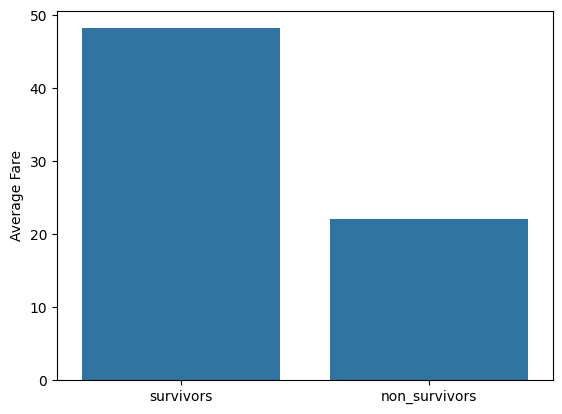

In [209]:
ax=sns.barplot(x=["survivors","non_survivors"],y=[average_fare_for_survivors,average_fare_for_non_survivors])
ax.set( ylabel="Average Fare")


In [210]:
figure=px.bar(x=["survivors","non_survivors"],y=[average_fare_for_survivors,average_fare_for_non_survivors])
figure.update_layout(xaxis_title='Average no.of survivors and non-survivors', yaxis_title='Average Fare')


#### Question 6 — Combined: Gender + Class together
####


In [211]:
survivied=(df[df['Sex']=="female"][df['Pclass']==1]['Survived'].sum())/ (df[df['Sex']=="female"][df['Pclass']==1].shape[0])*100


In [212]:
survivied

np.float64(96.73913043478261)

In [213]:
survivied=(df[df['Sex']=="male"][df['Pclass']==3]['Survived'].sum())/ (df[df['Sex']=="male"][df['Pclass']==3].shape[0])*100


In [214]:
survivied

np.float64(13.544668587896252)

### Visualization ###

#### Chart 1 — Survival Count (Bar Chart) ####



In [215]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [216]:
data=df.groupby("Survived").value_counts()
data

Survived  PassengerId  Pclass  Name                                                 Sex     Age   SibSp  Parch  Ticket    Fare      Cabin        Embarked
0         7            1       McCarthy, Mr. Timothy J                              male    54.0  0      0      17463     51.8625   E46          S           1
          28           1       Fortune, Mr. Charles Alexander                       male    19.0  3      2      19950     263.0000  C23 C25 C27  S           1
          63           1       Harris, Mr. Henry Birkhardt                          male    45.0  1      0      36973     83.4750   C83          S           1
          97           1       Goldschmidt, Mr. George B                            male    71.0  0      0      PC 17754  34.6542   A5           C           1
          76           3       Moen, Mr. Sigurd Hansen                              male    25.0  0      0      348123    7.6500    F G73        S           1
                                                   

<Axes: xlabel='Survived', ylabel='count'>

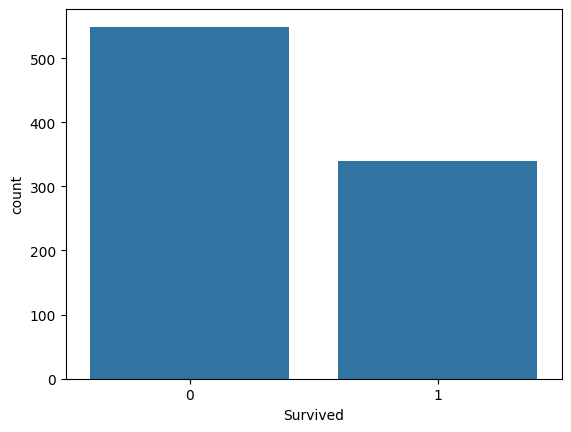

In [217]:
# sns.barplot(y=data.index,x=data.values)
from re import X


sns.countplot(x="Survived",data=df)

#### Chart 2 — Survival by Gender (Bar Chart) ####



In [218]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

<Axes: xlabel='Sex', ylabel='count'>

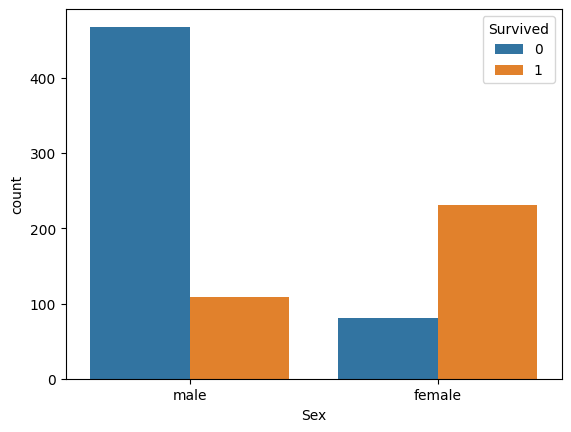

In [220]:
sns.countplot(x="Sex",hue="Survived",data=df)

#### Chart 3 — Survival by Class (Bar Chart) ####



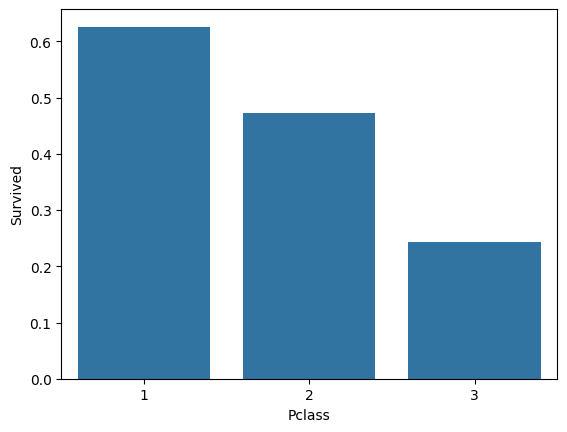

In [223]:
import seaborn as sns
import matplotlib.pyplot as plt

data = df.groupby("Pclass")["Survived"].mean().reset_index()

sns.barplot(x="Pclass", y="Survived", data=data)

plt.show()

#### Chart 4 — Age Distribution (Histogram) ####



In [224]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

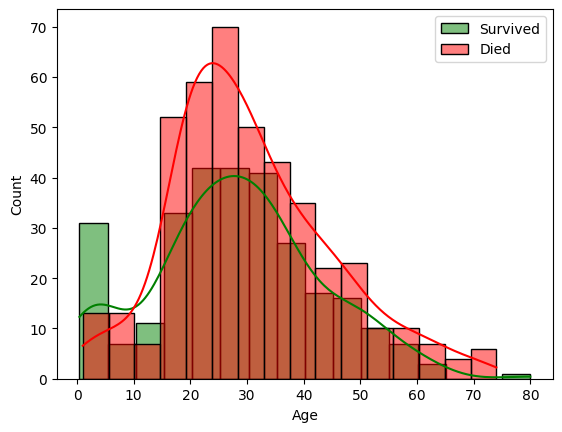

np.float64(8119.67)

In [232]:
import seaborn as sns
import matplotlib.pyplot as plt
# survivors
sns.histplot(df[df['Survived'] == 1]['Age'], 
             color='green', 
             label='Survived', 
             kde=True,
             alpha=0.5)

# non-survivors
sns.histplot(df[df['Survived'] == 0]['Age'], 
             color='red', 
             label='Died', 
             kde=True,
             alpha=0.5)

plt.legend()
plt.show()
df[df['Survived'] == 1]['Age'].sum().round(2)

#### Chart 5 — Heatmap: Gender + Class Combined ####

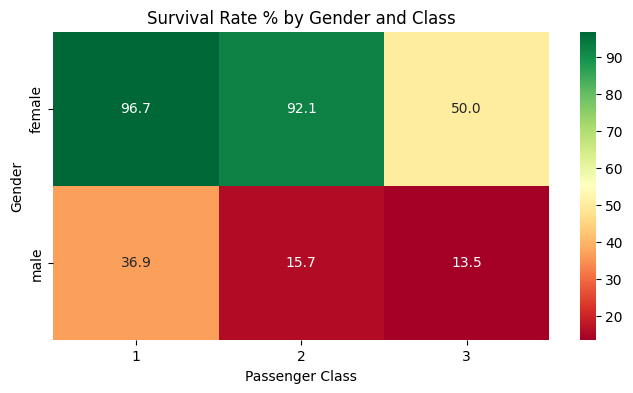

In [233]:
pivot = df.pivot_table(values='Survived', 
                        index='Sex', 
                        columns='Pclass', 
                        aggfunc='mean') * 100

plt.figure(figsize=(8,4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn')
plt.title('Survival Rate % by Gender and Class')
plt.xlabel('Passenger Class')
plt.ylabel('Gender')
plt.show()